In [32]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt, medfilt
from scipy.stats import zscore

# Load data
with open("../data/raw/WESAD/S2/S2.pkl", "rb") as f:
    data = pickle.load(f, encoding="latin1")

# Extract EDA
wrist_eda = data['signal']['wrist']['EDA'].flatten()
chest_eda = data['signal']['chest']['EDA'].flatten()

#median filter
def clean_eda(signal,fs):
      # Step 1: remove spikes
    signal_med = medfilt(signal, kernel_size=5)

    # Step 2: smooth signal
    b, a = butter(
        4,
        0.2/(fs/2),
        btype='low'
    )

    signal_filt = filtfilt(b, a, signal_med)

    return signal_filt

In [33]:
wrist_eda_filtered = clean_eda(
    wrist_eda,
    fs=4
)

chest_eda_filtered = clean_eda(
    chest_eda,
    fs=700
)

CELL 2 — Filter Wrist & Chest EDA + STD

In [34]:
# Sampling rates
fs_wrist = 4
fs_chest = 700

# Filter signals
wrist_eda_filtered = filter_eda(
    wrist_eda,
    fs_wrist
)

chest_eda_filtered = filter_eda(
    chest_eda,
    fs_chest
)

# STD comparison

print("========== WRIST EDA ==========")
print("Raw STD      :", np.std(wrist_eda))
print("Filtered STD :", np.std(wrist_eda_filtered))

print("\n========== CHEST EDA ==========")
print("Raw STD      :", np.std(chest_eda))
print("Filtered STD :", np.std(chest_eda_filtered))

========== WRIST EDA ==========
Raw STD      : 0.3292287628310672
Filtered STD : 0.32859487066552584

========== CHEST EDA ==========
Raw STD      : 1.238424840251518
Filtered STD : 1.2382152671253208


CELL 3 — ALL PLOTS

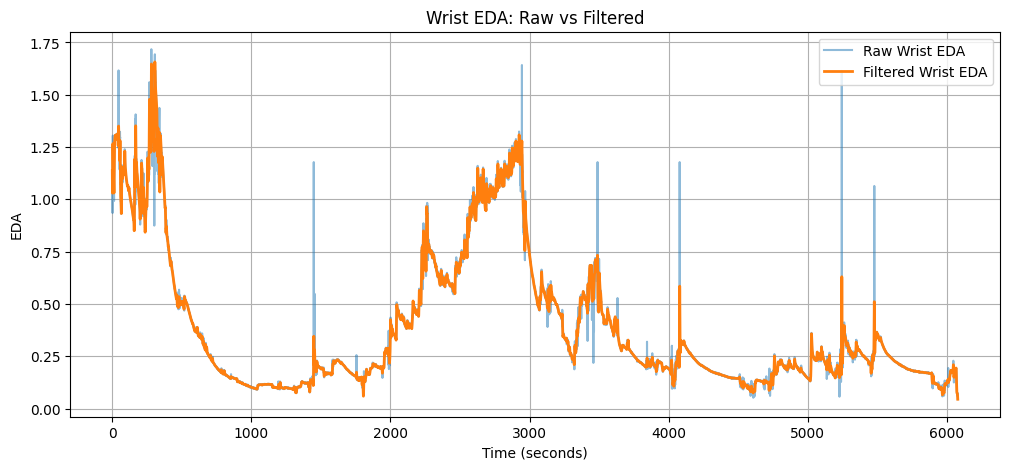

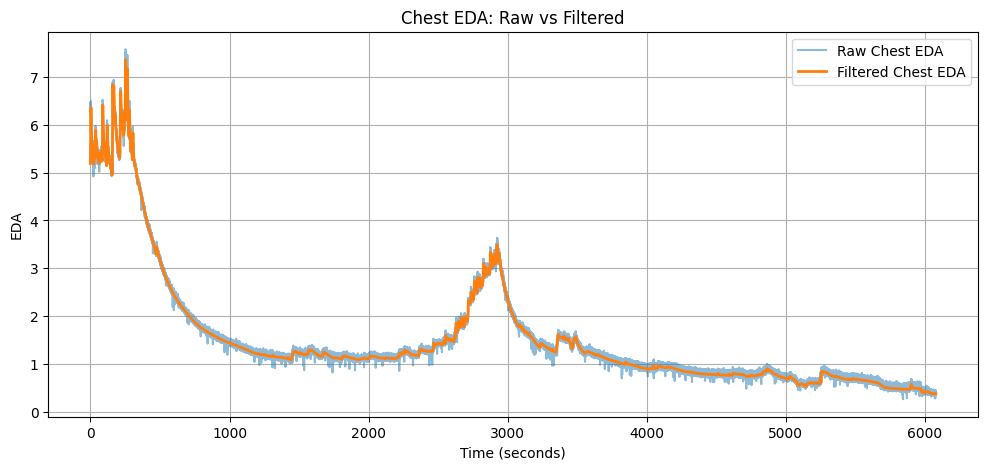

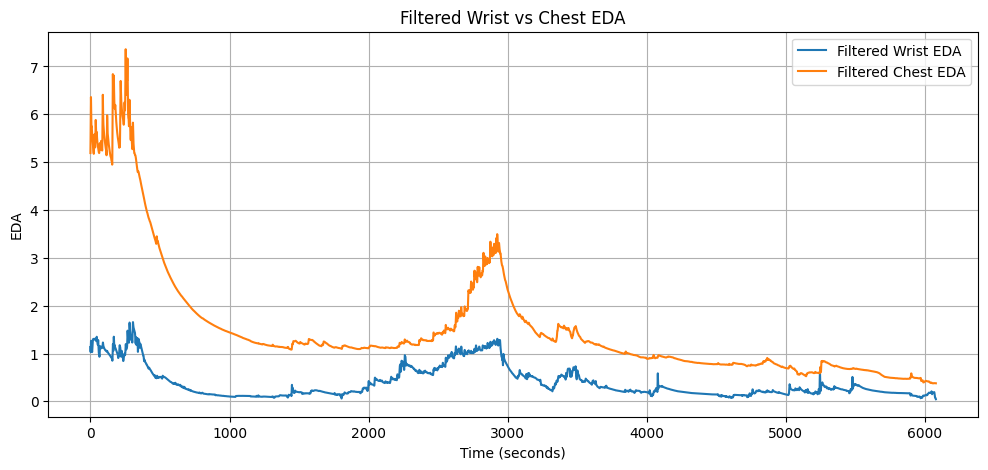

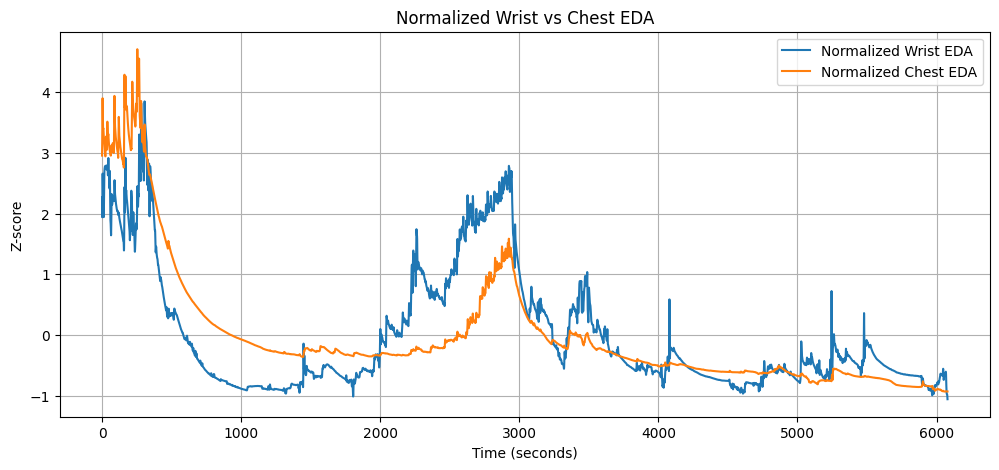

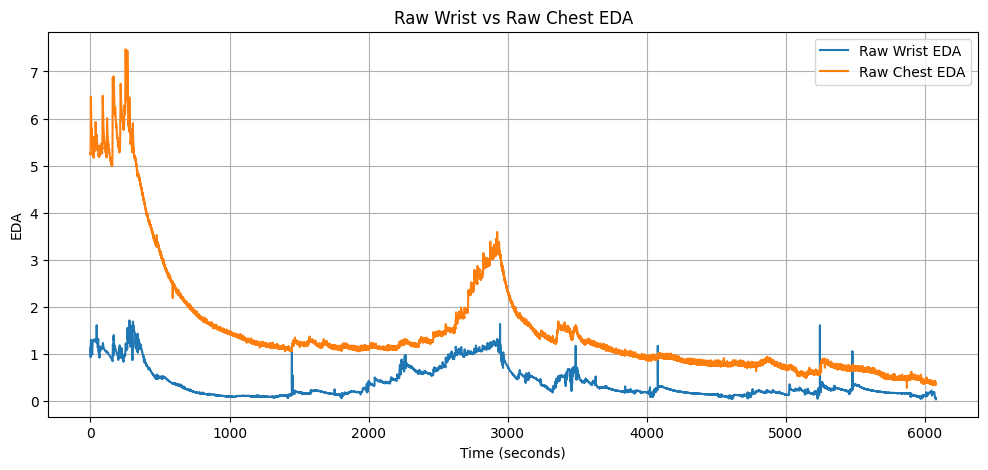

In [35]:
# ---------------------------
# RAW vs FILTERED WRIST EDA
# ---------------------------

time_wrist = np.arange(len(wrist_eda))/fs_wrist

plt.figure(figsize=(12,5))

plt.plot(
    time_wrist,
    wrist_eda,
    label="Raw Wrist EDA",
    alpha=0.5
)

plt.plot(
    time_wrist,
    wrist_eda_filtered,
    label="Filtered Wrist EDA",
    linewidth=2
)

plt.title("Wrist EDA: Raw vs Filtered")
plt.xlabel("Time (seconds)")
plt.ylabel("EDA")

plt.legend()
plt.grid()

plt.show()


# ---------------------------
# RAW vs FILTERED CHEST EDA
# ---------------------------

time_chest = np.arange(len(chest_eda))/fs_chest

plt.figure(figsize=(12,5))

plt.plot(
    time_chest,
    chest_eda,
    label="Raw Chest EDA",
    alpha=0.5
)

plt.plot(
    time_chest,
    chest_eda_filtered,
    label="Filtered Chest EDA",
    linewidth=2
)

plt.title("Chest EDA: Raw vs Filtered")
plt.xlabel("Time (seconds)")
plt.ylabel("EDA")

plt.legend()
plt.grid()

plt.show()


# ---------------------------
# DOWNSAMPLE CHEST
# ---------------------------

chest_eda_ds = chest_eda_filtered[::175]

min_len = min(
    len(wrist_eda_filtered),
    len(chest_eda_ds)
)

wrist_comp = wrist_eda_filtered[:min_len]
chest_comp = chest_eda_ds[:min_len]

time = np.arange(min_len)/4


# ---------------------------
# FILTERED WRIST vs CHEST
# ---------------------------

plt.figure(figsize=(12,5))

plt.plot(
    time,
    wrist_comp,
    label="Filtered Wrist EDA"
)

plt.plot(
    time,
    chest_comp,
    label="Filtered Chest EDA"
)

plt.title("Filtered Wrist vs Chest EDA")
plt.xlabel("Time (seconds)")
plt.ylabel("EDA")

plt.legend()
plt.grid()

plt.show()


# ---------------------------
# NORMALIZED WRIST vs CHEST
# ---------------------------

plt.figure(figsize=(12,5))

plt.plot(
    time,
    zscore(wrist_comp),
    label="Normalized Wrist EDA"
)

plt.plot(
    time,
    zscore(chest_comp),
    label="Normalized Chest EDA"
)

plt.title("Normalized Wrist vs Chest EDA")
plt.xlabel("Time (seconds)")
plt.ylabel("Z-score")

plt.legend()
plt.grid()

plt.show()


# ---------------------------
# RAW WRIST vs RAW CHEST
# ---------------------------

chest_raw_ds = chest_eda[::175]

min_len_raw = min(
    len(wrist_eda),
    len(chest_raw_ds)
)

plt.figure(figsize=(12,5))

plt.plot(
    np.arange(min_len_raw)/4,
    wrist_eda[:min_len_raw],
    label="Raw Wrist EDA"
)

plt.plot(
    np.arange(min_len_raw)/4,
    chest_raw_ds[:min_len_raw],
    label="Raw Chest EDA"
)

plt.title("Raw Wrist vs Raw Chest EDA")
plt.xlabel("Time (seconds)")
plt.ylabel("EDA")

plt.legend()
plt.grid()

plt.show()

CELL 4 — Functions for Noise, Spikes, and Drift

In [36]:
from scipy.stats import zscore, linregress

# -------------------------
# Noise
# -------------------------

def calculate_noise(signal):
    return np.std(np.diff(signal))


# -------------------------
# Spikes
# -------------------------

def detect_spikes(signal, threshold=3):

    z = np.abs(zscore(signal))

    spikes = np.where(z > threshold)[0]

    return spikes


# -------------------------
# Drift
# -------------------------

def calculate_drift(signal):

    x = np.arange(len(signal))

    slope, _, _, _, _ = linregress(
        x,
        signal
    )

    return slope

In [37]:
print("========== WRIST EDA ==========")

print("Raw Noise Level      :", calculate_noise(wrist_eda))
print("Filtered Noise Level :", calculate_noise(wrist_eda_filtered))

print("Raw Spike Count      :", len(detect_spikes(wrist_eda)))
print("Filtered Spike Count :", len(detect_spikes(wrist_eda_filtered)))

print("Raw Drift Slope      :", calculate_drift(wrist_eda))
print("Filtered Drift Slope :", calculate_drift(wrist_eda_filtered))

print("\n")

print("========== CHEST EDA ==========")

print("Raw Noise Level      :", calculate_noise(chest_eda))
print("Filtered Noise Level :", calculate_noise(chest_eda_filtered))

print("Raw Spike Count      :", len(detect_spikes(chest_eda)))
print("Filtered Spike Count :", len(detect_spikes(chest_eda_filtered)))

print("Raw Drift Slope      :", calculate_drift(chest_eda))
print("Filtered Drift Slope :", calculate_drift(chest_eda_filtered))

========== WRIST EDA ==========
Raw Noise Level      : 0.01886522909564867
Filtered Noise Level : 0.003715000481894521
Raw Spike Count      : 139
Filtered Spike Count : 127
Raw Drift Slope      : -1.8021900479117574e-05
Filtered Drift Slope : -1.802442998595381e-05


========== CHEST EDA ==========
Raw Noise Level      : 0.026198855703604192
Filtered Noise Level : 4.4786830348549455e-05
Raw Spike Count      : 192777
Filtered Spike Count : 194716
Raw Drift Slope      : -6.731387448146534e-07
Filtered Drift Slope : -6.731778407029759e-07


In [38]:
def detect_spikes_diff(signal, threshold=5):

    diff = np.abs(np.diff(signal))

    spikes = np.where(
        diff > threshold*np.std(diff)
    )[0]

    return spikes

In [39]:
print("Raw Wrist Spikes:",
      len(detect_spikes_diff(wrist_eda)))

print("Filtered Wrist Spikes:",
      len(detect_spikes_diff(wrist_eda_filtered)))

Raw Wrist Spikes: 92
Filtered Wrist Spikes: 243


In [40]:
print("Raw Chest Spikes:",
      len(detect_spikes_diff(chest_eda)))

print("Filtered Chest Spikes:",
      len(detect_spikes_diff(chest_eda_filtered)))

Raw Chest Spikes: 21639
Filtered Chest Spikes: 36256


In [41]:
print("Raw diff std:",
      np.std(np.diff(chest_eda)))

print("Filtered diff std:",
      np.std(np.diff(chest_eda_filtered)))

Raw diff std: 0.026198855703604192
Filtered diff std: 4.4786830348549455e-05
